In [2]:

import pandas as pd        
import numpy as np          
import matplotlib.pyplot as plt
import seaborn as sns      

In [4]:
df = pd.read_csv('../data/train.csv')

In [5]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


first identifying missing values in all columns

In [6]:
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

Missing values per column:
Age         177
Cabin       687
Embarked      2
dtype: int64


Then , determining the highest embarked value

In [7]:
print("Embarked value counts:")
print(df['Embarked'].value_counts())

Embarked value counts:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


Most value is S, so fill missing values with S

In [8]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

Comfirms no more missing Embarked values

In [9]:
print("\nMissing in Embarked:", df['Embarked'].isnull().sum())


Missing in Embarked: 0


Age: first knowing median and mean of age of the dataset

In [10]:
print("Age median:", df['Age'].median())
print("Age mean:", df['Age'].mean())

Age median: 28.0
Age mean: 29.69911764705882


filling missing ages with the median


In [11]:
df['Age'] = df['Age'].fillna(df['Age'].median())

Confirming no missing age gaps

In [12]:
print("Missing in Age:", df['Age'].isnull().sum())

Missing in Age: 0


Cabin: Extracting first letter of cabin, if missing, it is labellled unknown

In [13]:
df['Deck'] = df['Cabin'].apply(lambda x: x[0] if pd.notna(x) else 'Unknown')


Viewing current decks

In [14]:
print(df['Deck'].value_counts())


Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


Unknown cabin removed and dropped, and usefull information is extracted from Cabin

In [15]:
df = df.drop(columns=['Cabin'])
print("\nCabin dropped. Deck column created.")


Cabin dropped. Deck column created.


Checking for any dupllicated in the columns, if not, dataset is clean 

In [16]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


Checking sex column values for any inconsistencies

In [17]:
print("Sex values:", df['Sex'].unique())

Sex values: <StringArray>
['male', 'female']
Length: 2, dtype: str


Handling outliers in Fare and Age

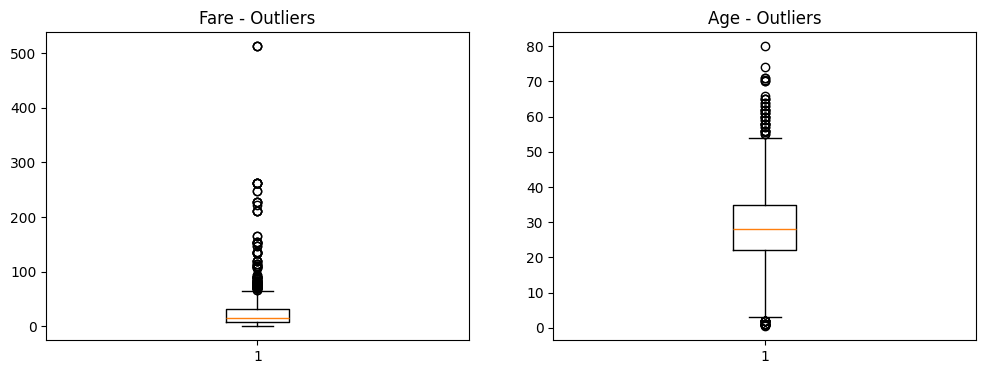

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].boxplot(df['Fare'])
axes[0].set_title('Fare - Outliers')

axes[1].boxplot(df['Age'])
axes[1].set_title('Age - Outliers')

plt.show()

In [21]:
fare_cap = df['Fare'].quantile(0.99)
df['Fare'] = df['Fare'].clip(upper=fare_cap)

print("Fare capped at:", fare_cap)

Fare capped at: 247.66934200000009


Fare capped at 0.99 percentile

Confirming no more missing vales left in the dataset

In [23]:
print("\nRemaining missing values:")
print(df.isnull().sum()[df.isnull().sum() > 0])


Remaining missing values:
Series([], dtype: int64)


No missing value, now saving clean dataset as train_cleaned.csv

In [25]:
df.to_csv('../data/train_cleaned.csv', index=False)
print("Cleaned dataset saved!")

Cleaned dataset saved!


PART 2: FEATURE ENGINEERING

1)Creating derived features

Countingg the number of family members including themselves (+1)

In [26]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

People travelling alone, 1 if alone, 0 if travelling with family

In [27]:
df['IsAlone'] = (df['FamilySize'] == 1).astype(int)

In [28]:
print(df[['SibSp', 'Parch', 'FamilySize', 'IsAlone']].head(10))

   SibSp  Parch  FamilySize  IsAlone
0      1      0           2        0
1      1      0           2        0
2      0      0           1        1
3      1      0           2        0
4      0      0           1        1
5      0      0           1        1
6      0      0           1        1
7      3      1           5        0
8      0      2           3        0
9      1      0           2        0


Title extraction from names, first we view all names

In [30]:
print(df['Name'].head(10))

0                              Braund, Mr. Owen Harris
1    Cumings, Mrs. John Bradley (Florence Briggs Th...
2                               Heikkinen, Miss. Laina
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                             Allen, Mr. William Henry
5                                     Moran, Mr. James
6                              McCarthy, Mr. Timothy J
7                       Palsson, Master. Gosta Leonard
8    Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)
9                  Nasser, Mrs. Nicholas (Adele Achem)
Name: Name, dtype: str


Title comes in the middle, extracting the word that comes before the (.) Counts the number of all titles on board

In [32]:
df['Title'] = df['Name'].str.extract(r',\s*([^\.]+)\.'); print(df['Title'].value_counts())

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64


Grouping rare titles together for a cleaner view

In [33]:

df['Title'] = df['Title'].replace({
    'Mlle': 'Miss',  
    'Ms': 'Miss',
    'Mme': 'Mrs',    
    'Lady': 'Rare',
    'Countess': 'Rare',
    'Capt': 'Rare',
    'Col': 'Rare',
    'Don': 'Rare',
    'Dr': 'Rare',
    'Major': 'Rare',
    'Rev': 'Rare',
    'Sir': 'Rare',
    'Jonkheer': 'Rare',
    'Dona': 'Rare'
})

print(df['Title'].value_counts())

Title
Mr              517
Miss            185
Mrs             126
Master           40
Rare             22
the Countess      1
Name: count, dtype: int64


Determining age groups and viewing distribution on board

In [34]:

df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 12, 18, 60, 100],
                         labels=['Child', 'Teen', 'Adult', 'Senior'])


print(df['AgeGroup'].value_counts())

AgeGroup
Adult     730
Teen       70
Child      69
Senior     22
Name: count, dtype: int64


Adult 18-60, teen 12-18, child 0-12, senior 60-100 count distribution as shown above

Fare per person where Fare / FamilySize

In [36]:
df['FarePerPerson'] = df['Fare'] / df['FamilySize']
print(df[['Fare', 'FamilySize', 'FarePerPerson']].head(10))

      Fare  FamilySize  FarePerPerson
0   7.2500           2        3.62500
1  71.2833           2       35.64165
2   7.9250           1        7.92500
3  53.1000           2       26.55000
4   8.0500           1        8.05000
5   8.4583           1        8.45830
6  51.8625           1       51.86250
7  21.0750           5        4.21500
8  11.1333           3        3.71110
9  30.0708           2       15.03540


Deck extraction from cabin

In [37]:
print("Deck value counts:")
print(df['Deck'].value_counts())

Deck value counts:
Deck
Unknown    687
C           59
B           47
D           33
E           32
A           15
F           13
G            4
T            1
Name: count, dtype: int64


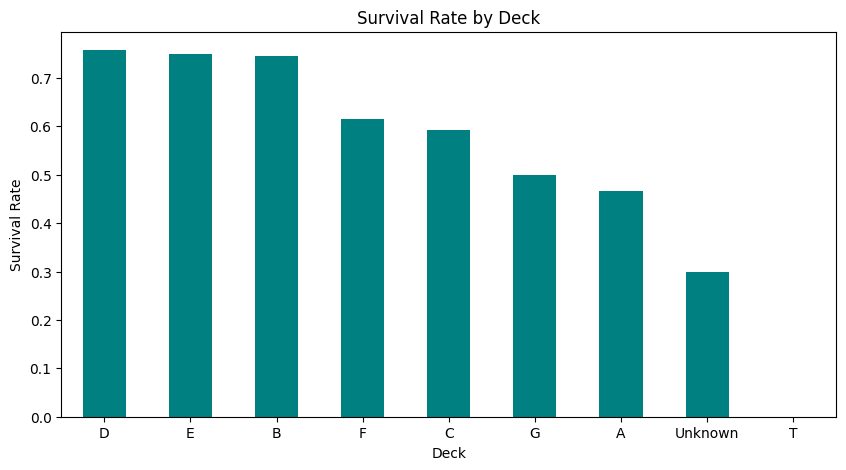

In [38]:
plt.figure(figsize=(10, 5))
df.groupby('Deck')['Survived'].mean().sort_values(ascending=False).plot(
    kind='bar', color='teal')
plt.title('Survival Rate by Deck')
plt.xlabel('Deck')
plt.ylabel('Survival Rate')
plt.xticks(rotation=0)
plt.show()

Cabins D and E(mixiture of middle class) were closely positioned to reach lifeboats quickly, hence higher survival rates. 
Cabins A,B,C (first class decks) not nearly positioned to lifeboats hence lower survival rate comparatively. 
T shows zero( had one person)

In [39]:

df['Deck'] = df['Deck'].replace('T', 'Unknown')
print("Deck T removed. Updated counts:")
print(df['Deck'].value_counts())

Deck T removed. Updated counts:
Deck
Unknown    688
C           59
B           47
D           33
E           32
A           15
F           13
G            4
Name: count, dtype: int64


T has been replaced to unknown and Unknown count updated 

Visualization of the new features

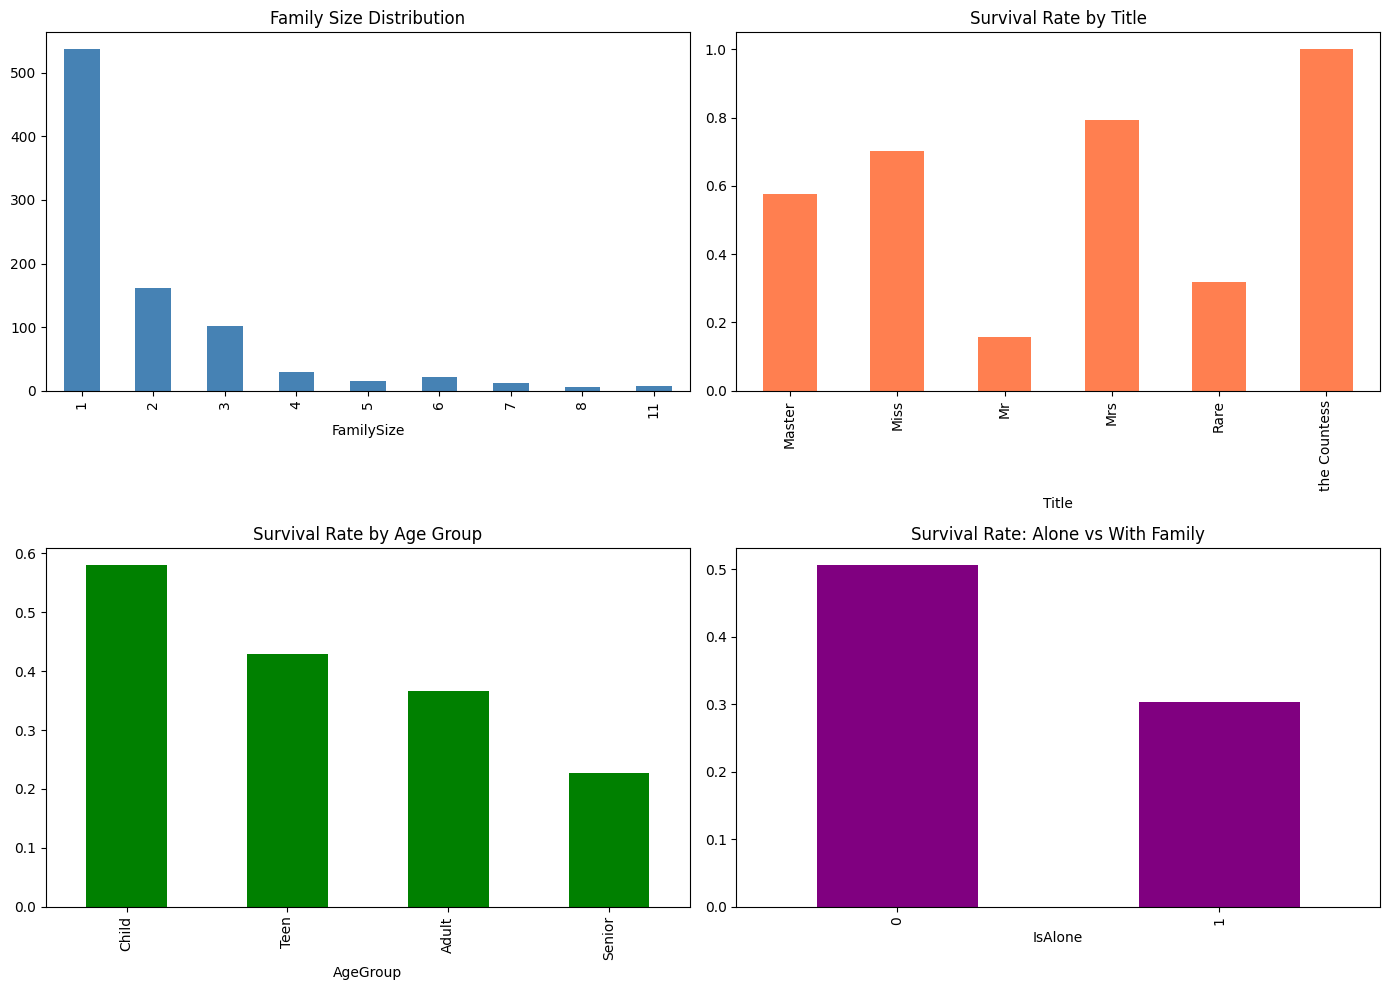

In [43]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# FamilySize distribution
df['FamilySize'].value_counts().sort_index().plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Family Size Distribution')

# Survival by Title
df.groupby('Title')['Survived'].mean().plot(kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title('Survival Rate by Title')

# Survival by AgeGroup
df.groupby('AgeGroup', observed=True)['Survived'].mean().plot(kind='bar', ax=axes[1,0], color='green')
axes[1,0].set_title('Survival Rate by Age Group')

# Survival by IsAlone
df.groupby('IsAlone')['Survived'].mean().plot(kind='bar', ax=axes[1,1], color='purple')
axes[1,1].set_title('Survival Rate: Alone vs With Family')

plt.tight_layout()
plt.show()

Family size:Smaller sized families survived more. 
Title: Mrs and MIss survived more than Mr. (females were prioritised).
Age: Children survived more (children were prioritised first for rescue).
IsAlone: People with family survive more than those alone.

In [44]:
# Drop columns we no longer need before encoding
df = df.drop(columns=['Name', 'Ticket', 'PassengerId'])

# One-hot encode all categorical text columns
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Title', 'Deck', 'AgeGroup'],
                    drop_first=True)

print("New shape after encoding:", df.shape)
print("\nAll columns:")
print(df.columns.tolist())

New shape after encoding: (891, 27)

All columns:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Sex_male', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare', 'Title_the Countess', 'Deck_B', 'Deck_C', 'Deck_D', 'Deck_E', 'Deck_F', 'Deck_G', 'Deck_Unknown', 'AgeGroup_Teen', 'AgeGroup_Adult', 'AgeGroup_Senior']


Name: Dropped because Title was already extracted, the rest is invalid. Ticket: is a random number hence has no learnable pattern. PassengerId: dropped because it has no significant effect on a persons survival . On-hot code converted value to numbers for machine to understand eg Sex-male set to 1 or 0 (in stead of male and female)

Fare skewness before: 3.1
Fare skewness after log: 0.33


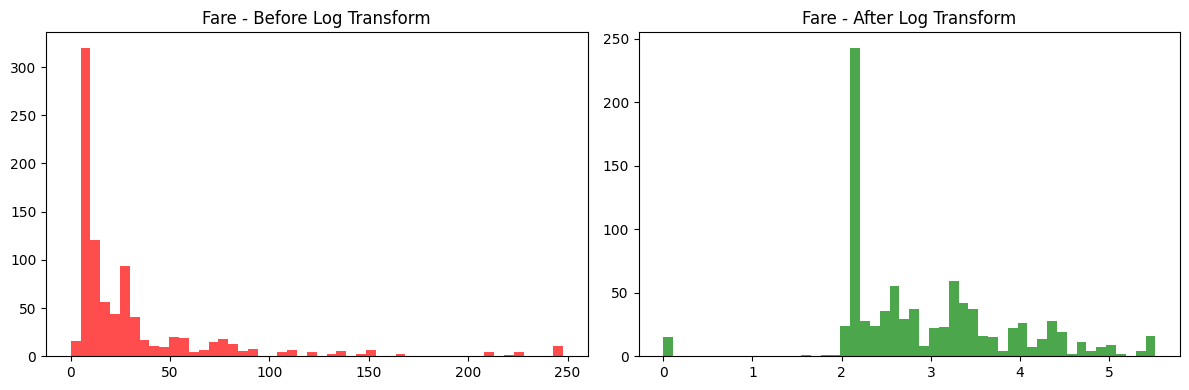

In [45]:
# Check skewness before
print("Fare skewness before:", round(df['Fare'].skew(), 2))

# Log transform
df['Fare_log'] = np.log1p(df['Fare'])

# Check skewness after
print("Fare skewness after log:", round(df['Fare_log'].skew(), 2))

# Visualise before and after
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['Fare'], bins=50, color='red', alpha=0.7)
axes[0].set_title('Fare - Before Log Transform')
axes[1].hist(df['Fare_log'], bins=50, color='green', alpha=0.7)
axes[1].set_title('Fare - After Log Transform')
plt.tight_layout()
plt.show()

PART 3: FEATURE SELECTION- Maintaning the most relevant columns


First we see what columns we have

In [46]:
print("Shape:", df.shape)
print("\nAll columns:")
for col in df.columns:
    print(col)

Shape: (891, 28)

All columns:
Survived
Pclass
Age
SibSp
Parch
Fare
FamilySize
IsAlone
FarePerPerson
Sex_male
Embarked_Q
Embarked_S
Title_Miss
Title_Mr
Title_Mrs
Title_Rare
Title_the Countess
Deck_B
Deck_C
Deck_D
Deck_E
Deck_F
Deck_G
Deck_Unknown
AgeGroup_Teen
AgeGroup_Adult
AgeGroup_Senior
Fare_log


In [47]:

df = df.drop(columns=['Title_the Countess'])
#Removing this column because it has too few people to matter, it was to be added among rare. Cannot be added since encoding already happened, hence we are dropping it
print("Fixed. Shape now:", df.shape)

Fixed. Shape now: (891, 27)


1)Correlation analysis: Seeing how relevant each column is to survival, remove irrelevant/ redundant columns.

In [48]:
# Calculate correlation of every column with Survived
correlation = df.corr()['Survived'].sort_values(ascending=False)
print(correlation)

Survived           1.000000
Title_Mrs          0.341994
Title_Miss         0.335636
Fare_log           0.329308
Fare               0.273195
FarePerPerson      0.246486
Deck_B             0.175095
Deck_D             0.150716
Deck_E             0.145321
Deck_C             0.114652
Parch              0.081629
Deck_F             0.057935
AgeGroup_Teen      0.026859
FamilySize         0.016639
Deck_G             0.016040
Embarked_Q         0.003650
Title_Rare        -0.021481
SibSp             -0.035322
AgeGroup_Senior   -0.051224
Age               -0.064910
AgeGroup_Adult    -0.079185
Embarked_S        -0.149683
IsAlone           -0.203367
Deck_Unknown      -0.319572
Pclass            -0.338481
Sex_male          -0.543351
Title_Mr          -0.549199
Name: Survived, dtype: float64


Close to 1-Highly correlated to survival. Close to -1 -Closer to death. Close to 0-Has little or no relationship to survival

Visualizing correlations

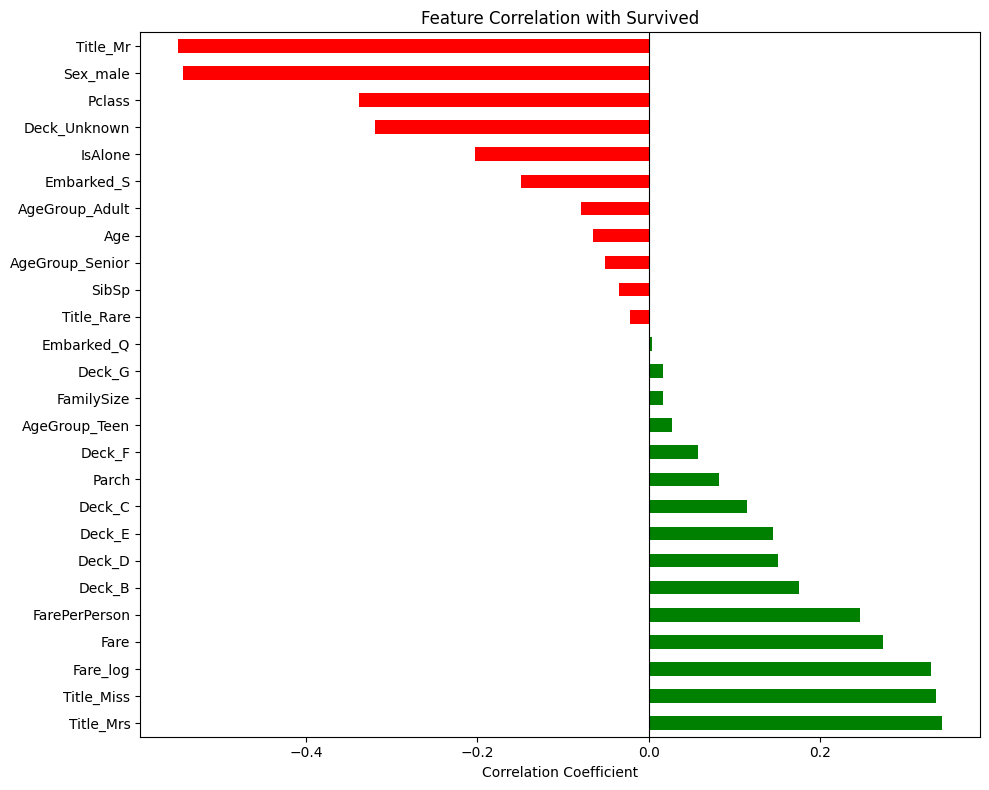

In [49]:
plt.figure(figsize=(10, 8))
correlation.drop('Survived').plot(kind='barh', color=[
    'green' if v > 0 else 'red' for v in correlation.drop('Survived')
])
plt.title('Feature Correlation with Survived')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

Green bars = positively correlated with survival
Red bars = negatively correlated with survival

2) Feature Importance Using Random Forest

In [51]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

# Separate features (X) from target (y)
X = df.drop(columns=['Survived'])
y = df['Survived']

# Train a quick Random Forest just to measure importance
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get feature importances
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=False)

print("Feature Importances:")
print(importance)

Feature Importances:
Age                0.165468
Title_Mr           0.138026
FarePerPerson      0.108129
Sex_male           0.102440
Fare_log           0.101988
Fare               0.093892
Pclass             0.044660
FamilySize         0.040802
Title_Miss         0.034422
Title_Mrs          0.028562
SibSp              0.022226
Deck_Unknown       0.021720
Embarked_S         0.016572
Parch              0.012913
AgeGroup_Adult     0.010881
Title_Rare         0.007915
IsAlone            0.007759
Deck_E             0.007047
Embarked_Q         0.006777
Deck_C             0.006406
Deck_D             0.005126
AgeGroup_Teen      0.004755
AgeGroup_Senior    0.004531
Deck_B             0.004300
Deck_F             0.001693
Deck_G             0.000988
dtype: float64


Visualizing feature importance

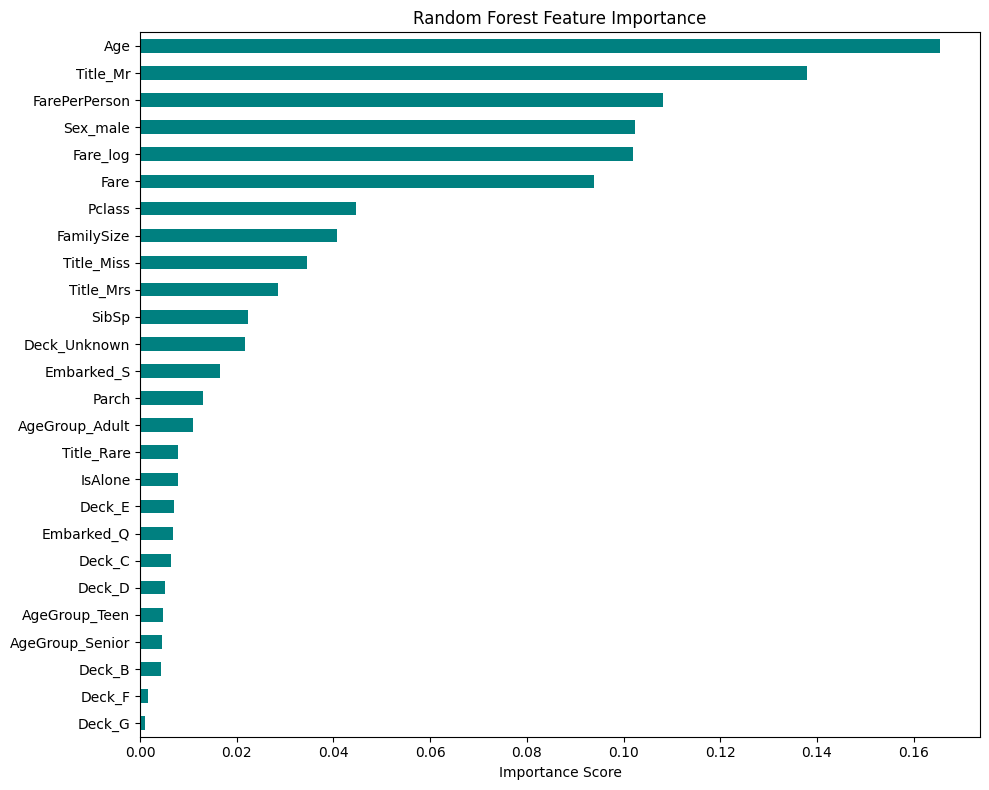

In [52]:
plt.figure(figsize=(10, 8))
importance.plot(kind='barh', color='teal')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

What this tells you:
Features at the top = most useful for predicting survival
Features at the bottom = adding little value, candidates for dropping

Now , we drop weeakest features

In [53]:
# Drop features with very low importance (below 0.01 threshold)
weak_features = importance[importance < 0.01].index.tolist()
print("Dropping weak features:", weak_features)

df_selected = df.drop(columns=weak_features)
print("\nFinal shape:", df_selected.shape)
print("\nSelected features:")
print(df_selected.columns.tolist())

Dropping weak features: ['Title_Rare', 'IsAlone', 'Deck_E', 'Embarked_Q', 'Deck_C', 'Deck_D', 'AgeGroup_Teen', 'AgeGroup_Senior', 'Deck_B', 'Deck_F', 'Deck_G']

Final shape: (891, 16)

Selected features:
['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'FarePerPerson', 'Sex_male', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Deck_Unknown', 'AgeGroup_Adult', 'Fare_log']


Saving the final dataset

In [54]:
df_selected.to_csv('../data/train_engineered.csv', index=False)
print("Final engineered dataset saved!")
print(f"Started with 12 columns, ended with {df_selected.shape[1]} powerful features.")

Final engineered dataset saved!
Started with 12 columns, ended with 16 powerful features.
